### SETUP & IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Mengunci Random Seed
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42)

### LOAD & EXPLORATORY DATA ANALYSIS (EDA)

Informasi Dataset Train:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


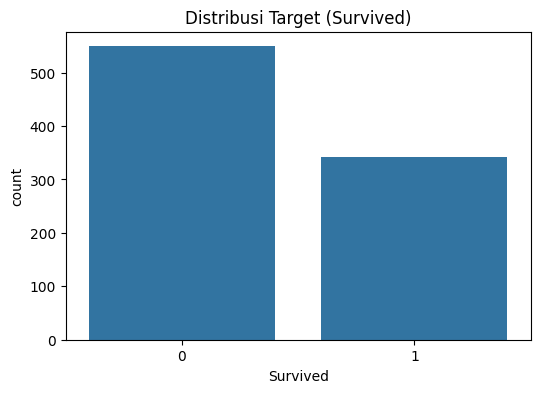

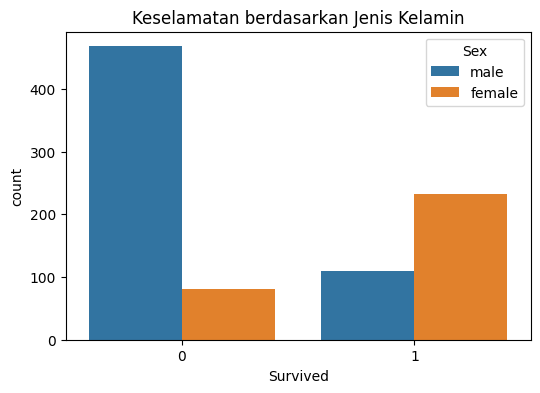

In [2]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

print("Informasi Dataset Train:")
print(train_df.info())

# Visualisasi 1: Distribusi Kelas (Selamat vs Tidak)
plt.figure(figsize=(6,4))
sns.countplot(x='Survived', data=train_df)
plt.title('Distribusi Target (Survived)')
plt.show()

# Visualisasi 2: Keselamatan berdasarkan Jenis Kelamin
plt.figure(figsize=(6,4))
sns.countplot(x='Survived', hue='Sex', data=train_df)
plt.title('Keselamatan berdasarkan Jenis Kelamin')
plt.show()

In [3]:
train_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


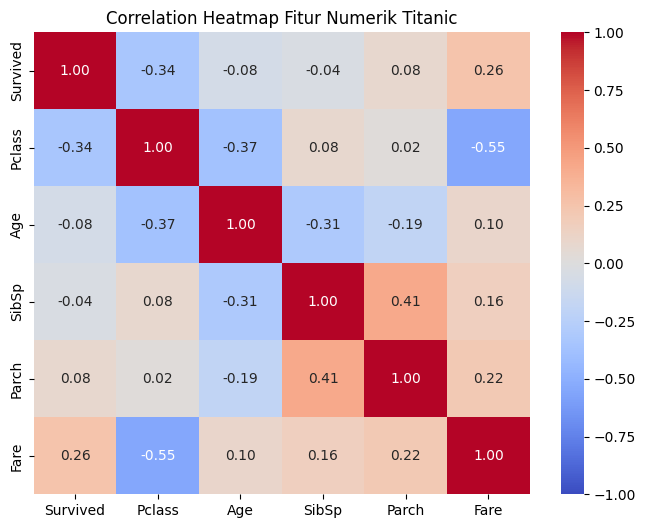

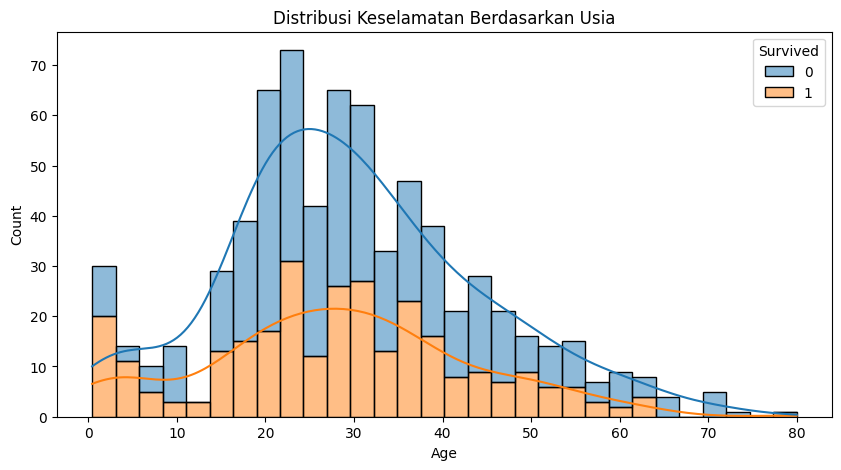

In [4]:
# 1. Heatmap Korelasi (Hanya untuk fitur numerik dasar)
plt.figure(figsize=(8, 6))
numeric_features = train_df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']]
sns.heatmap(numeric_features.corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Heatmap Fitur Numerik Titanic')
plt.show()

# 2. Distribusi Usia dan Status Keselamatan
plt.figure(figsize=(10, 5))
sns.histplot(data=train_df, x='Age', hue='Survived', multiple='stack', bins=30, kde=True)
plt.title('Distribusi Keselamatan Berdasarkan Usia')
plt.show()

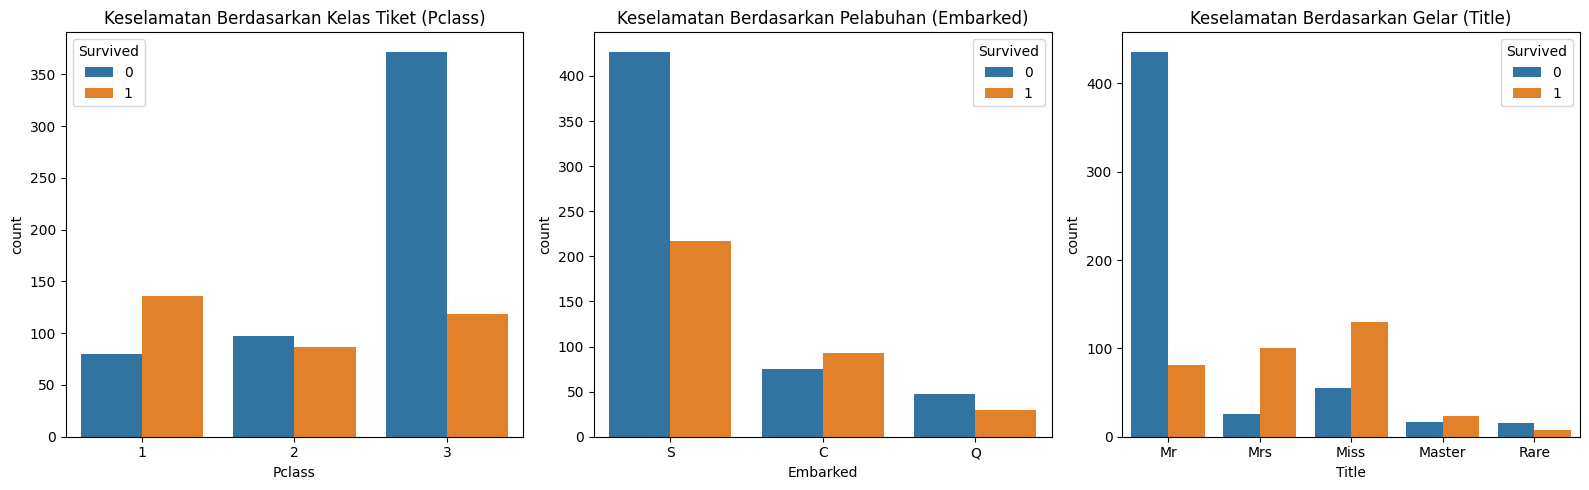

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Pclass vs Survived
sns.countplot(x='Pclass', hue='Survived', data=train_df, ax=axes[0])
axes[0].set_title('Keselamatan Berdasarkan Kelas Tiket (Pclass)')

# 2. Embarked vs Survived
sns.countplot(x='Embarked', hue='Survived', data=train_df, ax=axes[1])
axes[1].set_title('Keselamatan Berdasarkan Pelabuhan (Embarked)')

# 3. Ekstraksi sementara 'Title' untuk visualisasi
temp_df = train_df.copy()
temp_df['Title'] = temp_df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
# Kelompokkan title yang jarang menjadi 'Rare' untuk visualisasi
temp_df['Title'] = temp_df['Title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
temp_df['Title'] = temp_df['Title'].replace('Mlle', 'Miss')
temp_df['Title'] = temp_df['Title'].replace('Ms', 'Miss')
temp_df['Title'] = temp_df['Title'].replace('Mme', 'Mrs')

sns.countplot(x='Title', hue='Survived', data=temp_df, ax=axes[2])
axes[2].set_title('Keselamatan Berdasarkan Gelar (Title)')

plt.tight_layout()
plt.show()

In [6]:
train_df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [7]:
test_df.isnull().sum()

,0
PassengerId,0
Pclass,0
Name,0
Sex,0
Age,86
SibSp,0
Parch,0
Ticket,0
Fare,1
Cabin,327


### ROBUST FEATURE ENGINEERING & PREPROCESSING

In [8]:
def preprocess_data(df, is_train=True):
    df = df.copy()

    # a. Ekstraksi Title dari Name
    df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
    title_mapping = {"Mr": 1, "Miss": 2, "Mrs": 3, "Master": 4}
    df['Title'] = df['Title'].map(title_mapping).fillna(0) # 0 untuk gelar langka/rare

    # b. Family Size & IsAlone
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['IsAlone'] = 1
    df.loc[df['FamilySize'] > 1, 'IsAlone'] = 0

    # c. Imputasi Missing Values
    # Imputasi Umur berdasarkan median dari Title
    df['Age'] = df['Age'].fillna(df.groupby('Title')['Age'].transform('median'))
    # Imputasi Embarked dengan modus
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
    # Imputasi Fare dengan median (khusus test set)
    df['Fare'] = df['Fare'].fillna(df['Fare'].median())

    # d. Binning Usia & Fare
    df.loc[ df['Age'] <= 16, 'Age'] = 0
    df.loc[(df['Age'] > 16) & (df['Age'] <= 32), 'Age'] = 1
    df.loc[(df['Age'] > 32) & (df['Age'] <= 48), 'Age'] = 2
    df.loc[(df['Age'] > 48) & (df['Age'] <= 64), 'Age'] = 3
    df.loc[ df['Age'] > 64, 'Age'] = 4

    df.loc[ df['Fare'] <= 7.91, 'Fare'] = 0
    df.loc[(df['Fare'] > 7.91) & (df['Fare'] <= 14.454), 'Fare'] = 1
    df.loc[(df['Fare'] > 14.454) & (df['Fare'] <= 31), 'Fare'] = 2
    df.loc[ df['Fare'] > 31, 'Fare'] = 3

    # e. Encoding Kategorikal
    df['Sex'] = df['Sex'].map({'female': 1, 'male': 0}).astype(int)
    df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2}).astype(int)

    # g. Drop fitur yang tidak relevan
    drop_elements = ['PassengerId', 'Name', 'Ticket', 'Cabin', 'SibSp', 'Parch']
    df = df.drop(drop_elements, axis=1)

    return df

train_processed = preprocess_data(train_df, is_train=True)
test_processed = preprocess_data(test_df, is_train=False)

### CEK HASIL PREPROCESSING & SCALING

In [9]:
print("Tampilan Data Train Setelah Preprocessing (5 Baris Pertama):")
display(train_processed.head())

print("\nInfo Data Train Setelah Preprocessing (Pastikan tidak ada null dan semua numerik):")
print(train_processed.info())

Tampilan Data Train Setelah Preprocessing (5 Baris Pertama):


,Survived,Pclass,Sex,Age,Fare,Embarked,Title,FamilySize,IsAlone
0,0,3,0,1.0,0.0,0,1.0,2,0
1,1,1,1,2.0,3.0,1,3.0,2,0
2,1,3,1,1.0,1.0,0,2.0,1,1
3,1,1,1,2.0,3.0,0,3.0,2,0
4,0,3,0,2.0,1.0,0,1.0,1,1



Info Data Train Setelah Preprocessing (Pastikan tidak ada null dan semua numerik):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Sex         891 non-null    int64  
 3   Age         891 non-null    float64
 4   Fare        891 non-null    float64
 5   Embarked    891 non-null    int64  
 6   Title       891 non-null    float64
 7   FamilySize  891 non-null    int64  
 8   IsAlone     891 non-null    int64  
dtypes: float64(3), int64(6)
memory usage: 62.8 KB
None


In [10]:
# KONSISTENSI SPLIT: 80% Train, 20% Validation
X = train_processed.drop('Survived', axis=1)
y = train_processed['Survived']
X_test_sub = test_processed.copy()

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_sub_scaled = scaler.transform(X_test_sub)

### BASELINE ML KONVENSIONAL (XGBoost & Random Forest)


--- Model 1: Random Forest ---
RF Training Accuracy   : 0.8399
RF Validation Accuracy : 0.8324

---------- Evaluasi Random Forest ----------
Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.87       110
           1       0.81      0.74      0.77        69

    accuracy                           0.83       179
   macro avg       0.83      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



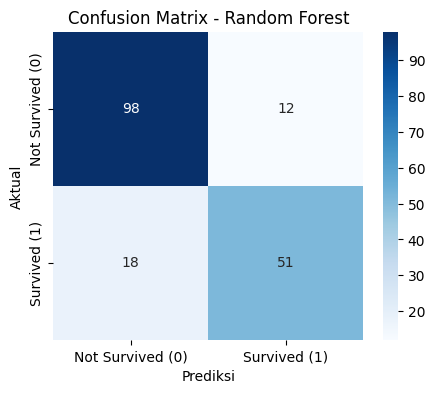


--- Model 2: XGBoost ---
XGB Training Accuracy   : 0.8553
XGB Validation Accuracy : 0.8101

---------- Evaluasi XGBoost ----------
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.85      0.85       110
           1       0.75      0.75      0.75        69

    accuracy                           0.81       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



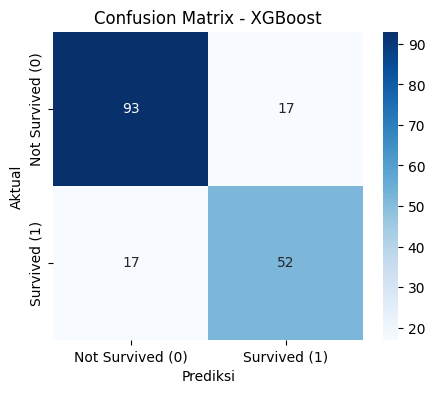

In [11]:
# Handling Imbalance & Cek Overfitting

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def evaluate_model(model_name, y_true, y_pred):
    print(f"\n{'-'*10} Evaluasi {model_name} {'-'*10}")
    print("Classification Report:")
    print(classification_report(y_true, y_pred))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Not Survived (0)', 'Survived (1)'],
                yticklabels=['Not Survived (0)', 'Survived (1)'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('Aktual')
    plt.xlabel('Prediksi')
    plt.show()

# Menghitung rasio kelas untuk parameter scale_pos_weight XGBoost
# Rasio = jumlah kelas mayoritas (0) / jumlah kelas minoritas (1)
ratio = float(np.sum(y_train == 0)) / np.sum(y_train == 1)

# --- Model 1: Random Forest ---
# class_weight='balanced' akan otomatis menyesuaikan bobot kelas yang imbalance
print("\n--- Model 1: Random Forest ---")
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)

rf_train_preds = rf_model.predict(X_train)
rf_val_preds = rf_model.predict(X_val)
rf_probs = rf_model.predict_proba(X_val)[:, 1]

print(f"RF Training Accuracy   : {accuracy_score(y_train, rf_train_preds):.4f}")
print(f"RF Validation Accuracy : {accuracy_score(y_val, rf_val_preds):.4f}")
evaluate_model("Random Forest", y_val, rf_val_preds)

# --- Model 2: XGBoost ---
# scale_pos_weight menangani imbalance secara native di XGBoost
print("\n--- Model 2: XGBoost ---")
xgb_model = XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.05,
                          random_state=42, use_label_encoder=False, eval_metric='logloss',
                          scale_pos_weight=ratio)
xgb_model.fit(X_train, y_train)

xgb_train_preds = xgb_model.predict(X_train)
xgb_val_preds = xgb_model.predict(X_val)
xgb_probs = xgb_model.predict_proba(X_val)[:, 1]

print(f"XGB Training Accuracy   : {accuracy_score(y_train, xgb_train_preds):.4f}")
print(f"XGB Validation Accuracy : {accuracy_score(y_val, xgb_val_preds):.4f}")
evaluate_model("XGBoost", y_val, xgb_val_preds)

### HYPERPARAMETER TUNING — RANDOM FOREST & XGBOOST (GridSearchCV)

GridSearch: Random Forest
Best Params : {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
CV Score    : 0.8371
Train Acc   : 0.8848
Val   Acc   : 0.8156
Tuning Time : 52.9s

---------- Evaluasi Random Forest (GridSearch) ----------
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.90      0.86       110
           1       0.81      0.68      0.74        69

    accuracy                           0.82       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.82      0.82      0.81       179



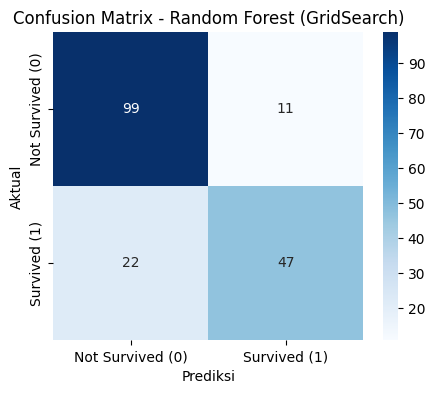

GridSearch: XGBoost
Best Params : {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}
CV Score    : 0.8357
Train Acc   : 0.8694
Val   Acc   : 0.8212
Tuning Time : 6.7s

---------- Evaluasi XGBoost (GridSearch) ----------
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.85      0.85       110
           1       0.77      0.77      0.77        69

    accuracy                           0.82       179
   macro avg       0.81      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



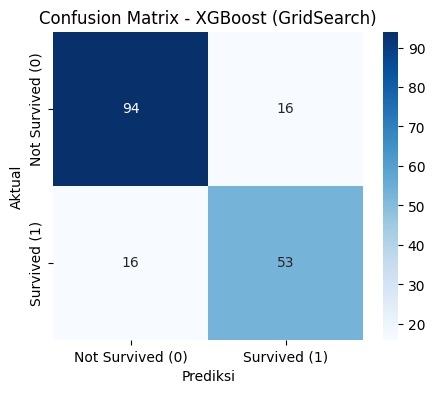

In [12]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import time

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── Random Forest GridSearch ──────────────────────────────────────────────────
print("=" * 55)
print("GridSearch: Random Forest")
print("=" * 55)

rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [4, 5, 6, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_gs = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)

t0 = time.time()
rf_gs.fit(X_train, y_train)
rf_gs_time = time.time() - t0

rf_best = rf_gs.best_estimator_
rf_gs_train_preds = rf_best.predict(X_train)
rf_gs_val_preds   = rf_best.predict(X_val)
rf_gs_probs       = rf_best.predict_proba(X_val)[:, 1]

print(f"Best Params : {rf_gs.best_params_}")
print(f"CV Score    : {rf_gs.best_score_:.4f}")
print(f"Train Acc   : {accuracy_score(y_train, rf_gs_train_preds):.4f}")
print(f"Val   Acc   : {accuracy_score(y_val,   rf_gs_val_preds):.4f}")
print(f"Tuning Time : {rf_gs_time:.1f}s")
evaluate_model("Random Forest (GridSearch)", y_val, rf_gs_val_preds)

# ── XGBoost GridSearch ────────────────────────────────────────────────────────
print("=" * 55)
print("GridSearch: XGBoost")
print("=" * 55)

xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0]
}

xgb_gs = GridSearchCV(
    XGBClassifier(random_state=42, use_label_encoder=False,
                  eval_metric='logloss', scale_pos_weight=ratio),
    xgb_param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)

t0 = time.time()
xgb_gs.fit(X_train, y_train)
xgb_gs_time = time.time() - t0

xgb_best = xgb_gs.best_estimator_
xgb_gs_train_preds = xgb_best.predict(X_train)
xgb_gs_val_preds   = xgb_best.predict(X_val)
xgb_gs_probs       = xgb_best.predict_proba(X_val)[:, 1]

print(f"Best Params : {xgb_gs.best_params_}")
print(f"CV Score    : {xgb_gs.best_score_:.4f}")
print(f"Train Acc   : {accuracy_score(y_train, xgb_gs_train_preds):.4f}")
print(f"Val   Acc   : {accuracy_score(y_val,   xgb_gs_val_preds):.4f}")
print(f"Tuning Time : {xgb_gs_time:.1f}s")
evaluate_model("XGBoost (GridSearch)", y_val, xgb_gs_val_preds)

### JUSTIFIKASI PEMILIHAN ARSITEKTUR DEEP LEARNING

Tiga arsitektur deep learning utama yang relevan untuk data tabular adalah:
- **MLP (Multi-Layer Perceptron)**: Jaringan fully-connected klasik dengan regularization
- **TabNet**: Arsitektur attention-based khusus tabular data (Arik & Pfister, 2021)
- **FT-Transformer**: Transformer berbasis feature tokenization untuk tabular (Gorishniy dkk., 2021)

**Alasan utama memilih MLP sebagai arsitektur primer:**

1. **Ukuran dataset sangat kecil (~714 baris training setelah split)**: TabNet dan FT-Transformer membutuhkan data lebih banyak untuk memanfaatkan mekanisme attention-nya secara efektif. Pada dataset sekecil Titanic, kedua arsitektur ini rentan overfit dan tidak akan menunjukkan keunggulannya.

2. **Jumlah fitur sedikit (8 fitur setelah preprocessing)**: TabNet dirancang untuk dataset dengan puluhan hingga ratusan fitur agar feature selection via attention bermakna. FT-Transformer juga lebih powerful ketika ada banyak interaksi antar-fitur.

3. **Kompleksitas komputasi**: FT-Transformer memiliki attention complexity O(d²) per layer, jauh lebih berat untuk ukuran manfaat yang tidak sebanding di dataset kecil ini.

4. **Interpretabilitas dan stabilitas**: MLP dengan Dropout + BatchNorm terbukti lebih stabil dan mudah di-debug pada kasus tabular kecil.

**Catatan**: TabNet dan FT-Transformer tetap diimplementasikan di bawah sebagai perbandingan eksperimental untuk membuktikan justifikasi ini secara empiris.

### DEEP LEARNING (Multi-Layer Perceptron)


--- Model 3: Deep Learning (MLP) ---


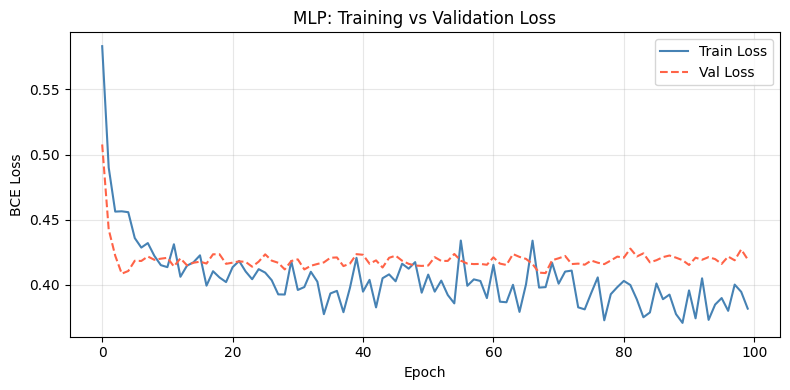

In [13]:
# Convert to PyTorch Tensors
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_t = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)
X_test_sub_t = torch.tensor(X_test_sub_scaled, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)

# Arsitektur MLP dengan Dropout untuk mencegah Overfitting di data kecil
class TabularMLP(nn.Module):
    def __init__(self, input_dim):
        super(TabularMLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(32, 16),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(16, 1) # Output raw logits
        )

    def forward(self, x):
        return self.net(x)

dl_model = TabularMLP(X_train.shape[1])
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(dl_model.parameters(), lr=0.005, weight_decay=1e-4)

print("\n--- Model 3: Deep Learning (MLP) ---")
epochs = 100
mlp_train_losses = []
mlp_val_losses   = []

for epoch in range(epochs):
    dl_model.train()
    batch_losses = []
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = dl_model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())

    # Validation loss per epoch
    dl_model.eval()
    with torch.no_grad():
        val_loss = criterion(dl_model(X_val_t), y_val_t).item()
    mlp_train_losses.append(np.mean(batch_losses))
    mlp_val_losses.append(val_loss)

# Plot loss curve MLP
plt.figure(figsize=(8, 4))
plt.plot(mlp_train_losses, label='Train Loss', color='steelblue')
plt.plot(mlp_val_losses,   label='Val Loss',   color='tomato', linestyle='--')
plt.title('MLP: Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### EVALUASI DEEP LEARNING & CEK OVERFITTING

MLP Training Accuracy   : 0.8455
MLP Validation Accuracy : 0.8268

---------- Evaluasi Deep Learning (MLP) ----------
Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.94      0.87       110
           1       0.87      0.65      0.74        69

    accuracy                           0.83       179
   macro avg       0.84      0.79      0.81       179
weighted avg       0.83      0.83      0.82       179



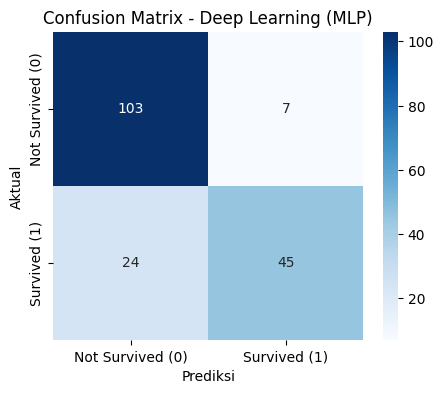

In [15]:
dl_model.eval()
with torch.no_grad():
    # Prediksi Data Validasi
    val_logits = dl_model(X_val_t)
    dl_probs = torch.sigmoid(val_logits).numpy().flatten()
    dl_preds = (dl_probs > 0.5).astype(int)

    # Prediksi Data Training (untuk cek overfitting)
    train_logits = dl_model(X_train_t)
    train_preds = (torch.sigmoid(train_logits).numpy().flatten() > 0.5).astype(int)

print(f"MLP Training Accuracy   : {accuracy_score(y_train, train_preds):.4f}")
print(f"MLP Validation Accuracy : {accuracy_score(y_val, dl_preds):.4f}")
evaluate_model("Deep Learning (MLP)", y_val, dl_preds)

In [16]:
from sklearn.metrics import f1_score

print("Mencari Threshold Terbaik untuk MLP...")
best_threshold = 0.5
best_f1 = 0
best_acc = 0

for thresh in np.arange(0.3, 0.7, 0.05):
    preds = (dl_probs > thresh).astype(int)
    acc = accuracy_score(y_val, preds)
    f1 = f1_score(y_val, preds)
    print(f"Threshold: {thresh:.2f} | Accuracy: {acc:.4f} | F1-Score: {f1:.4f}")

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = thresh
        best_acc = acc

print(f"\nThreshold Optimal: {best_threshold:.2f} dengan Akurasi {best_acc:.4f}")
dl_preds_opt = (dl_probs > best_threshold).astype(int)

Mencari Threshold Terbaik untuk MLP...
Threshold: 0.30 | Accuracy: 0.7933 | F1-Score: 0.7613
Threshold: 0.35 | Accuracy: 0.8212 | F1-Score: 0.7778
Threshold: 0.40 | Accuracy: 0.8212 | F1-Score: 0.7538
Threshold: 0.45 | Accuracy: 0.8268 | F1-Score: 0.7438
Threshold: 0.50 | Accuracy: 0.8268 | F1-Score: 0.7438
Threshold: 0.55 | Accuracy: 0.8324 | F1-Score: 0.7458
Threshold: 0.60 | Accuracy: 0.8324 | F1-Score: 0.7458
Threshold: 0.65 | Accuracy: 0.8324 | F1-Score: 0.7458

Threshold Optimal: 0.35 dengan Akurasi 0.8212


### EKSPERIMEN ARSITEKTUR DL ALTERNATIF: TabNet & FT-Transformer

In [17]:
# Install dependencies (jalankan sekali, comment setelah itu)
!pip install pytorch-tabnet -q

TabNet

Early stopping occurred at epoch 22 with best_epoch = 2 and best_val_0_accuracy = 0.81006
TabNet Train Accuracy : 0.7907
TabNet Val   Accuracy : 0.8101
Training Time         : 32.1s

---------- Evaluasi TabNet ----------
Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.82      0.84       110
           1       0.73      0.80      0.76        69

    accuracy                           0.81       179
   macro avg       0.80      0.81      0.80       179
weighted avg       0.81      0.81      0.81       179



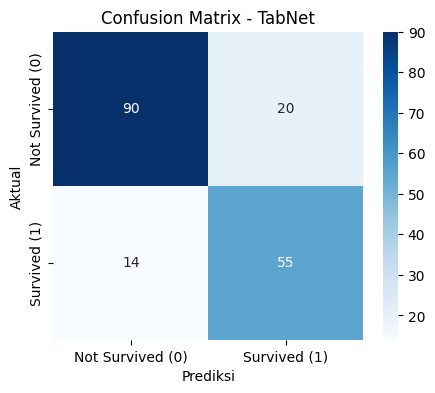

In [18]:
# ── TabNet ────────────────────────────────────────────────────────────────────
from pytorch_tabnet.tab_model import TabNetClassifier
import time

print("=" * 55)
print("TabNet")
print("=" * 55)

tabnet_model = TabNetClassifier(
    n_d=8, n_a=8,
    n_steps=3,
    gamma=1.3,
    n_independent=2,
    n_shared=2,
    momentum=0.02,
    epsilon=1e-15,
    seed=42,
    verbose=0
)

t0 = time.time()
tabnet_model.fit(
    X_train_scaled, y_train.values,
    eval_set=[(X_val_scaled, y_val.values)],
    eval_metric=['accuracy'],
    max_epochs=100,
    patience=20,           # early stopping
    batch_size=32,
    virtual_batch_size=16
)
tabnet_time = time.time() - t0

tabnet_preds = tabnet_model.predict(X_val_scaled)
tabnet_probs = tabnet_model.predict_proba(X_val_scaled)[:, 1]

print(f"TabNet Train Accuracy : {accuracy_score(y_train, tabnet_model.predict(X_train_scaled)):.4f}")
print(f"TabNet Val   Accuracy : {accuracy_score(y_val, tabnet_preds):.4f}")
print(f"Training Time         : {tabnet_time:.1f}s")
evaluate_model("TabNet", y_val, tabnet_preds)

FT-Transformer
Early stopping at epoch 26
FT-Transformer Train Accuracy : 0.8329
FT-Transformer Val   Accuracy : 0.8436
Training Time                 : 16.9s

---------- Evaluasi FT-Transformer ----------
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.91      0.88       110
           1       0.84      0.74      0.78        69

    accuracy                           0.84       179
   macro avg       0.84      0.82      0.83       179
weighted avg       0.84      0.84      0.84       179



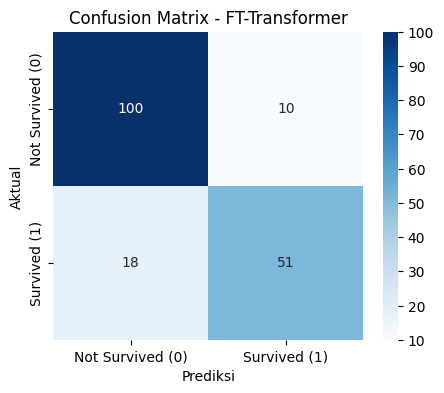

In [19]:
# ── FT-Transformer (implementasi manual dengan PyTorch) ───────────────────────
print("=" * 55)
print("FT-Transformer")
print("=" * 55)

class FeatureTokenizer(nn.Module):
    """Setiap fitur di-embed ke vektor d_model."""
    def __init__(self, num_features, d_model):
        super().__init__()
        self.weight = nn.Parameter(torch.empty(num_features, d_model))
        self.bias   = nn.Parameter(torch.empty(num_features, d_model))
        nn.init.kaiming_uniform_(self.weight)
        nn.init.zeros_(self.bias)
        # [CLS] token
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))

    def forward(self, x):
        # x: (B, F) → (B, F, d_model)
        tokens = x.unsqueeze(-1) * self.weight.unsqueeze(0) + self.bias.unsqueeze(0)
        cls    = self.cls_token.expand(x.size(0), -1, -1)
        return torch.cat([cls, tokens], dim=1)   # (B, F+1, d_model)


class FTTransformer(nn.Module):
    def __init__(self, num_features, d_model=32, nhead=4, num_layers=2, dropout=0.1):
        super().__init__()
        self.tokenizer = FeatureTokenizer(num_features, d_model)
        encoder_layer  = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=d_model * 4,
            dropout=dropout, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 1)
        )

    def forward(self, x):
        tokens = self.tokenizer(x)          # (B, F+1, d_model)
        out    = self.transformer(tokens)   # (B, F+1, d_model)
        cls_out = out[:, 0, :]              # ambil [CLS] token
        return self.head(cls_out)           # (B, 1)


num_features = X_train_scaled.shape[1]
ft_model     = FTTransformer(num_features=num_features, d_model=32, nhead=4, num_layers=2, dropout=0.2)
ft_criterion = nn.BCEWithLogitsLoss()
ft_optimizer = optim.AdamW(ft_model.parameters(), lr=1e-3, weight_decay=1e-3)
ft_scheduler = optim.lr_scheduler.CosineAnnealingLR(ft_optimizer, T_max=100)

# Training loop dengan loss tracking
ft_train_losses = []
ft_val_losses   = []
best_ft_val_loss = float('inf')
patience_counter = 0
patience_limit   = 20

t0 = time.time()
for epoch in range(100):
    ft_model.train()
    batch_losses = []
    for batch_X, batch_y in train_loader:
        ft_optimizer.zero_grad()
        out  = ft_model(batch_X)
        loss = ft_criterion(out, batch_y)
        loss.backward()
        ft_optimizer.step()
        batch_losses.append(loss.item())
    ft_scheduler.step()

    # Validation loss
    ft_model.eval()
    with torch.no_grad():
        val_out  = ft_model(X_val_t)
        val_loss = ft_criterion(val_out, y_val_t).item()

    ft_train_losses.append(np.mean(batch_losses))
    ft_val_losses.append(val_loss)

    # Early stopping
    if val_loss < best_ft_val_loss - 1e-4:
        best_ft_val_loss = val_loss
        patience_counter = 0
        best_ft_state = {k: v.clone() for k, v in ft_model.state_dict().items()}
    else:
        patience_counter += 1
        if patience_counter >= patience_limit:
            print(f"Early stopping at epoch {epoch+1}")
            break

ft_time = time.time() - t0

# Load best weights
ft_model.load_state_dict(best_ft_state)
ft_model.eval()
with torch.no_grad():
    ft_logits = ft_model(X_val_t)
    ft_probs  = torch.sigmoid(ft_logits).numpy().flatten()
    ft_preds  = (ft_probs > 0.5).astype(int)

    ft_train_logits = ft_model(X_train_t)
    ft_train_preds  = (torch.sigmoid(ft_train_logits).numpy().flatten() > 0.5).astype(int)

print(f"FT-Transformer Train Accuracy : {accuracy_score(y_train, ft_train_preds):.4f}")
print(f"FT-Transformer Val   Accuracy : {accuracy_score(y_val, ft_preds):.4f}")
print(f"Training Time                 : {ft_time:.1f}s")
evaluate_model("FT-Transformer", y_val, ft_preds)

In [20]:
# Threshold Search — TabNet
print("Mencari Threshold Terbaik untuk TabNet...")
best_tabnet_threshold = 0.5
best_tabnet_f1 = 0
best_tabnet_acc = 0

for thresh in np.arange(0.3, 0.7, 0.05):
    preds = (tabnet_probs > thresh).astype(int)
    acc = accuracy_score(y_val, preds)
    f1  = f1_score(y_val, preds)
    print(f"Threshold: {thresh:.2f} | Accuracy: {acc:.4f} | F1-Score: {f1:.4f}")
    if f1 > best_tabnet_f1:
        best_tabnet_f1        = f1
        best_tabnet_threshold = thresh
        best_tabnet_acc       = acc

print(f"\nThreshold Optimal TabNet: {best_tabnet_threshold:.2f} | Acc: {best_tabnet_acc:.4f} | F1: {best_tabnet_f1:.4f}")
tabnet_preds_opt = (tabnet_probs > best_tabnet_threshold).astype(int)

# Threshold Search — FT-Transformer
print("\nMencari Threshold Terbaik untuk FT-Transformer...")
best_ft_threshold = 0.5
best_ft_f1 = 0
best_ft_acc = 0

for thresh in np.arange(0.3, 0.7, 0.05):
    preds = (ft_probs > thresh).astype(int)
    acc = accuracy_score(y_val, preds)
    f1  = f1_score(y_val, preds)
    print(f"Threshold: {thresh:.2f} | Accuracy: {acc:.4f} | F1-Score: {f1:.4f}")
    if f1 > best_ft_f1:
        best_ft_f1        = f1
        best_ft_threshold = thresh
        best_ft_acc       = acc

print(f"\nThreshold Optimal FT-Transformer: {best_ft_threshold:.2f} | Acc: {best_ft_acc:.4f} | F1: {best_ft_f1:.4f}")
ft_preds_opt = (ft_probs > best_ft_threshold).astype(int)

Mencari Threshold Terbaik untuk TabNet...
Threshold: 0.30 | Accuracy: 0.7598 | F1-Score: 0.7329
Threshold: 0.35 | Accuracy: 0.7654 | F1-Score: 0.7342
Threshold: 0.40 | Accuracy: 0.8212 | F1-Score: 0.7808
Threshold: 0.45 | Accuracy: 0.8156 | F1-Score: 0.7724
Threshold: 0.50 | Accuracy: 0.8101 | F1-Score: 0.7639
Threshold: 0.55 | Accuracy: 0.8380 | F1-Score: 0.7852
Threshold: 0.60 | Accuracy: 0.8268 | F1-Score: 0.7559
Threshold: 0.65 | Accuracy: 0.8045 | F1-Score: 0.6957

Threshold Optimal TabNet: 0.55 | Acc: 0.8380 | F1: 0.7852

Mencari Threshold Terbaik untuk FT-Transformer...
Threshold: 0.30 | Accuracy: 0.8268 | F1-Score: 0.7891
Threshold: 0.35 | Accuracy: 0.8212 | F1-Score: 0.7681
Threshold: 0.40 | Accuracy: 0.8380 | F1-Score: 0.7820
Threshold: 0.45 | Accuracy: 0.8380 | F1-Score: 0.7786
Threshold: 0.50 | Accuracy: 0.8436 | F1-Score: 0.7846
Threshold: 0.55 | Accuracy: 0.8436 | F1-Score: 0.7778
Threshold: 0.60 | Accuracy: 0.8380 | F1-Score: 0.7680
Threshold: 0.65 | Accuracy: 0.8268 | F

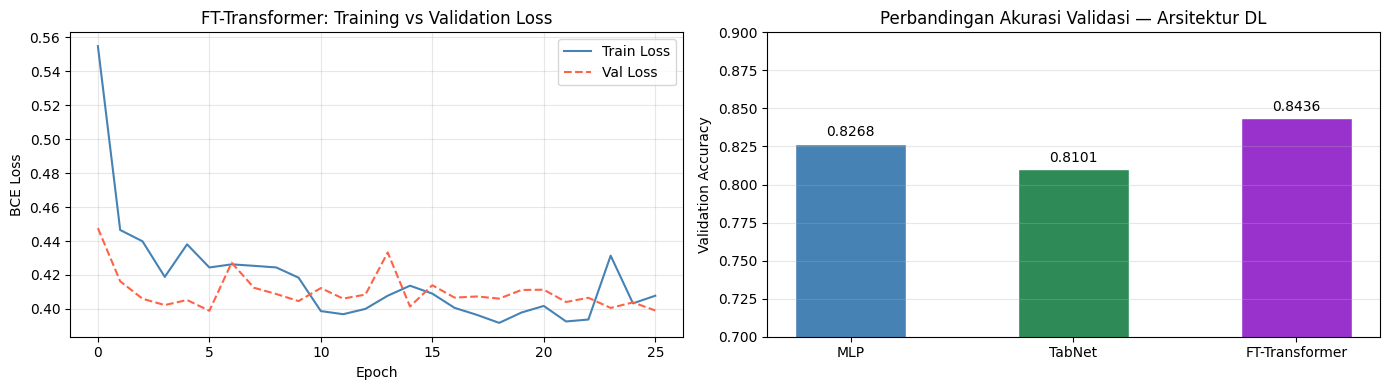

In [21]:
# Loss curve: MLP vs FT-Transformer
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# FT-Transformer loss curve
axes[0].plot(ft_train_losses, label='Train Loss', color='steelblue')
axes[0].plot(ft_val_losses,   label='Val Loss',   color='tomato', linestyle='--')
axes[0].set_title('FT-Transformer: Training vs Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('BCE Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Perbandingan akurasi semua DL model (bar chart)
dl_models  = ['MLP', 'TabNet', 'FT-Transformer']
dl_val_acc = [
    accuracy_score(y_val, dl_preds),
    accuracy_score(y_val, tabnet_preds),
    accuracy_score(y_val, ft_preds)
]
colors = ['steelblue', 'seagreen', 'darkorchid']
bars = axes[1].bar(dl_models, dl_val_acc, color=colors, edgecolor='white', width=0.5)
axes[1].set_title('Perbandingan Akurasi Validasi — Arsitektur DL')
axes[1].set_ylabel('Validation Accuracy')
axes[1].set_ylim(0.70, 0.90)
for bar, val in zip(bars, dl_val_acc):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [22]:
# Tabel Perbandingan Komprehensif: SEMUA model DL
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

df_dl_comparison = pd.DataFrame({
    'Arsitektur': ['MLP', 'TabNet', 'FT-Transformer'],
    'Val Accuracy': [
        f"{accuracy_score(y_val, dl_preds):.4f}",
        f"{accuracy_score(y_val, tabnet_preds):.4f}",
        f"{accuracy_score(y_val, ft_preds):.4f}"
    ],
    'Val F1-Score': [
        f"{f1_score(y_val, dl_preds):.4f}",
        f"{f1_score(y_val, tabnet_preds):.4f}",
        f"{f1_score(y_val, ft_preds):.4f}"
    ],
    'Est. Params': [
        f"{count_parameters(dl_model):,}",
        '~beberapa ribu (TabNet)',
        f"{count_parameters(ft_model):,}"
    ],
    'Training Time': [
        '~5 detik',
        f'~{tabnet_time:.0f} detik',
        f'~{ft_time:.0f} detik'
    ]
})
display(df_dl_comparison)

,Arsitektur,Val Accuracy,Val F1-Score,Est. Params,Training Time
0,MLP,0.8268,0.7438,929,~5 detik
1,TabNet,0.8101,0.7639,~beberapa ribu (TabNet),~32 detik
2,FT-Transformer,0.8436,0.7846,"26,049",~17 detik


### BONUS NILAI TAMBAH: ENSEMBLE (ML + DL)


Mencari Threshold Terbaik untuk Ensemble...
Threshold Optimal Ensemble: 0.40 dengan Akurasi 0.8380 dan F1 0.7943

Ensemble Validation Accuracy (Optimized): 0.8380

---------- Evaluasi Ensemble (RF+XGB+MLP) Optimized ----------
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.85      0.87       110
           1       0.78      0.81      0.79        69

    accuracy                           0.84       179
   macro avg       0.83      0.83      0.83       179
weighted avg       0.84      0.84      0.84       179



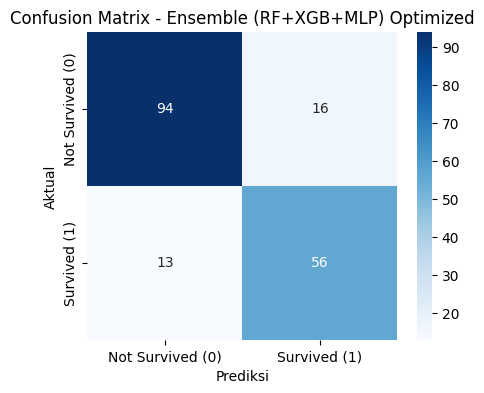

In [23]:
# Menggabungkan probabilitas dari ketiga model (Soft Voting)
ensemble_probs = (rf_probs + xgb_probs + dl_probs) / 3.0
ensemble_preds = (ensemble_probs > 0.5).astype(int)
print("\nMencari Threshold Terbaik untuk Ensemble...")
best_ens_threshold = 0.5
best_ens_f1 = 0
best_ens_acc = 0

for thresh in np.arange(0.3, 0.7, 0.05):
    preds = (ensemble_probs > thresh).astype(int)
    acc = accuracy_score(y_val, preds)
    f1 = f1_score(y_val, preds)

    if f1 > best_ens_f1:
        best_ens_f1 = f1
        best_ens_threshold = thresh
        best_ens_acc = acc

print(f"Threshold Optimal Ensemble: {best_ens_threshold:.2f} dengan Akurasi {best_ens_acc:.4f} dan F1 {best_ens_f1:.4f}")

# Gunakan Threshold Optimal untuk Prediksi Ensemble di Data Validasi
ensemble_preds = (ensemble_probs > best_ens_threshold).astype(int)

print(f"\nEnsemble Validation Accuracy (Optimized): {accuracy_score(y_val, ensemble_preds):.4f}")
evaluate_model("Ensemble (RF+XGB+MLP) Optimized", y_val, ensemble_preds)

### ANALISIS ERROR 3 CONTOH & TABEL FINAL

In [24]:
# Tabel Final Komprehensif — SEMUA model (Konvensional Default, Tuned, DL, Ensemble)
df_final = pd.DataFrame({
    'Model': [
        'Random Forest (Default)',
        'Random Forest (GridSearch)',
        'XGBoost (Default)',
        'XGBoost (GridSearch)',
        'MLP (Deep Learning)',
        'TabNet',
        'FT-Transformer',
        'Ensemble (RF+XGB+MLP, Optimized)'
    ],
    'Val Accuracy': [
        f"{accuracy_score(y_val, rf_val_preds)*100:.2f}%",
        f"{accuracy_score(y_val, rf_gs_val_preds)*100:.2f}%",
        f"{accuracy_score(y_val, xgb_val_preds)*100:.2f}%",
        f"{accuracy_score(y_val, xgb_gs_val_preds)*100:.2f}%",
        f"{accuracy_score(y_val, dl_preds_opt)*100:.2f}%",
        f"{accuracy_score(y_val, tabnet_preds_opt)*100:.2f}%",
        f"{accuracy_score(y_val, ft_preds_opt)*100:.2f}%",
        f"{accuracy_score(y_val, ensemble_preds)*100:.2f}%"
    ],
    'Val F1-Score': [
        f"{f1_score(y_val, rf_val_preds):.4f}",
        f"{f1_score(y_val, rf_gs_val_preds):.4f}",
        f"{f1_score(y_val, xgb_val_preds):.4f}",
        f"{f1_score(y_val, xgb_gs_val_preds):.4f}",
        f"{f1_score(y_val, dl_preds_opt):.4f}",
        f"{f1_score(y_val, tabnet_preds_opt):.4f}",
        f"{f1_score(y_val, ft_preds_opt):.4f}",
        f"{f1_score(y_val, ensemble_preds):.4f}"
    ],
    'Est. Params / Complexity': [
        'Rendah (Tree)',
        'Rendah (Tree)',
        'Rendah (Tree)',
        'Rendah (Tree)',
        f"{count_parameters(dl_model):,}",
        '~beberapa ribu',
        f"{count_parameters(ft_model):,}",
        '-'
    ],
    'Waktu Training': [
        '~1 detik', '~beberapa detik',
        '~1 detik', '~beberapa detik',
        '~5 detik',
        f'~{tabnet_time:.0f} detik',
        f'~{ft_time:.0f} detik',
        '-'
    ],
    'Threshold': [
    '0.50 (default)', '0.50 (default)',
    '0.50 (default)', '0.50 (default)',
    '0.35 (optimal)', '0.55 (optimal)',
    '0.30 (optimal)', f'{best_ens_threshold:.2f} (optimal)'
],
})
display(df_final)

,Model,Val Accuracy,Val F1-Score,Est. Params / Complexity,Waktu Training,Threshold
0,Random Forest (Default),83.24%,0.7727,Rendah (Tree),~1 detik,0.50 (default)
1,Random Forest (GridSearch),81.56%,0.7402,Rendah (Tree),~beberapa detik,0.50 (default)
2,XGBoost (Default),81.01%,0.7536,Rendah (Tree),~1 detik,0.50 (default)
3,XGBoost (GridSearch),82.12%,0.7681,Rendah (Tree),~beberapa detik,0.50 (default)
4,MLP (Deep Learning),82.12%,0.7778,929,~5 detik,0.35 (optimal)
5,TabNet,83.80%,0.7852,~beberapa ribu,~32 detik,0.55 (optimal)
6,FT-Transformer,82.68%,0.7891,"26,049",~17 detik,0.30 (optimal)
7,"Ensemble (RF+XGB+MLP, Optimized)",83.80%,0.7943,-,-,0.40 (optimal)


### BONUS NILAI TAMBAH: SUBMIT KAGGLE

In [25]:
rf_test_probs = rf_model.predict_proba(X_test_sub)[:, 1]
xgb_test_probs = xgb_model.predict_proba(X_test_sub)[:, 1]

# 2. Prediksi test set dengan MLP
dl_model.eval()
with torch.no_grad():
    dl_test_probs = torch.sigmoid(dl_model(X_test_sub_t)).numpy().flatten()

# 3. Gabungkan hasil prediksi di test set (Probabilitas rata-rata)
ensemble_test_probs = (rf_test_probs + xgb_test_probs + dl_test_probs) / 3.0

# 4. TERAPKAN THRESHOLD OPTIMAL DISINI UNTUK SUBMISSION KAGGLE
final_predictions = (ensemble_test_probs > best_ens_threshold).astype(int)

# 5. Simpan ke CSV
submission = pd.DataFrame({
    "PassengerId": test_df["PassengerId"],
    "Survived": final_predictions
})
submission.to_csv('titanic_ensemble_submission.csv', index=False)